In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Завантаження з правильними назвами колонок [cite: 19-36]
cols = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 
        'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 
        'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 
        'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 
        'city-mpg', 'highway-mpg', 'price']

df = pd.read_csv('automobile.csv', names=cols)

# 2. Data Cleaning: заміна '?' на NaN 
df.replace('?', np.nan, inplace=True)

# 3. Конвертація типів (щоб графіки працювали)
numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

# 4. Заповнення пропусків медіаною
df.fillna(df.median(numeric_only=True), inplace=True)
print("Очищення завершено. Пропусків більше немає.")

Очищення завершено. Пропусків більше немає.


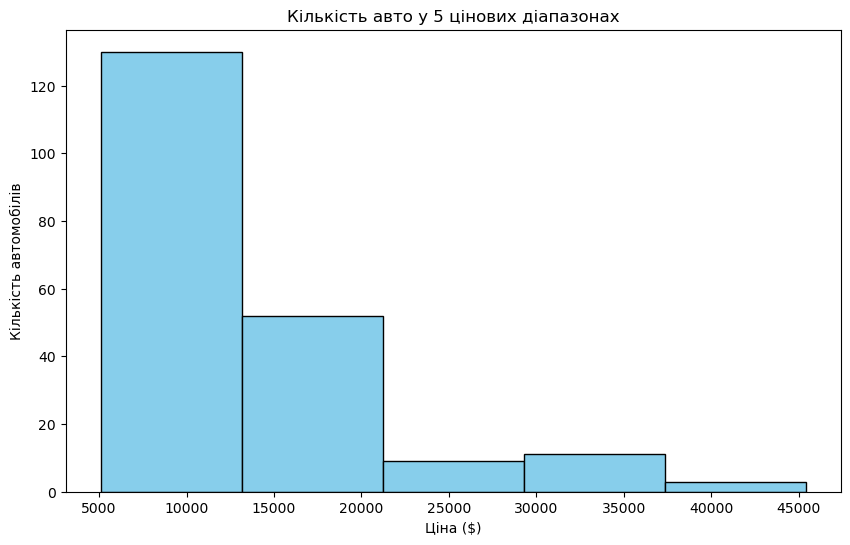

In [2]:
plt.figure(figsize=(10, 6))
# Параметр bins=5 забезпечує виконання умови про 5 діапазонів
plt.hist(df['price'], bins=5, color='skyblue', edgecolor='black')
plt.title('Кількість авто у 5 цінових діапазонах')
plt.xlabel('Ціна ($)')
plt.ylabel('Кількість автомобілів')
plt.show()

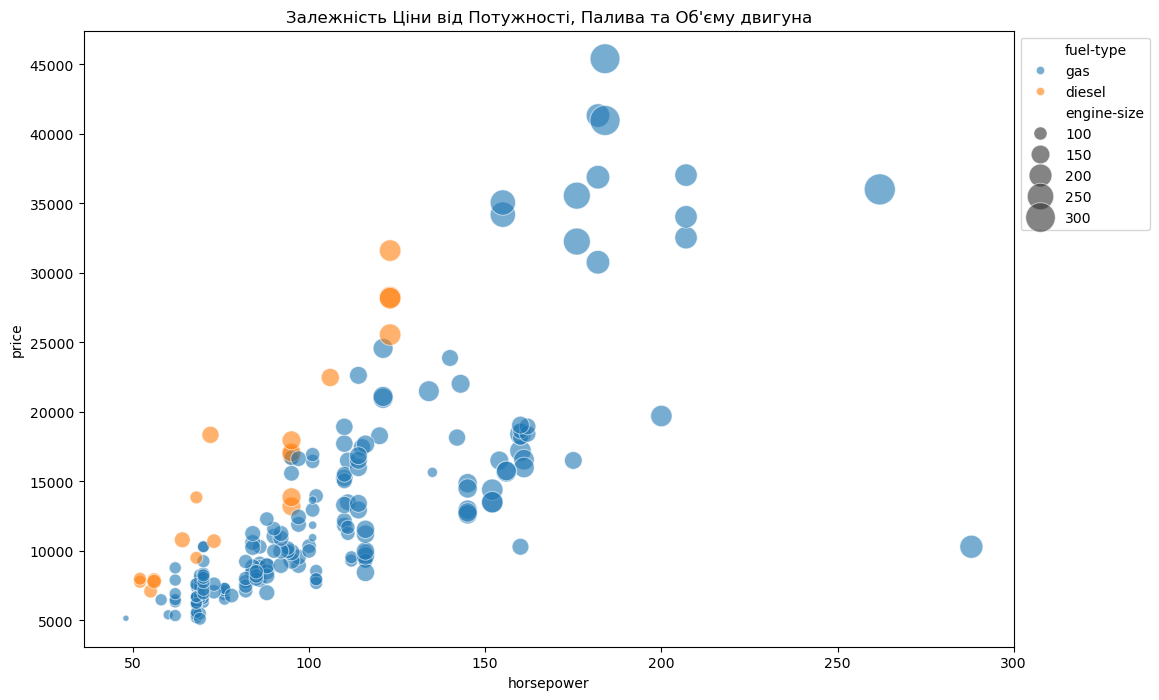

In [3]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='horsepower', y='price', 
                hue='fuel-type', size='engine-size', 
                sizes=(20, 500), alpha=0.6)
plt.title('Залежність Ціни від Потужності, Палива та Об\'єму двигуна')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

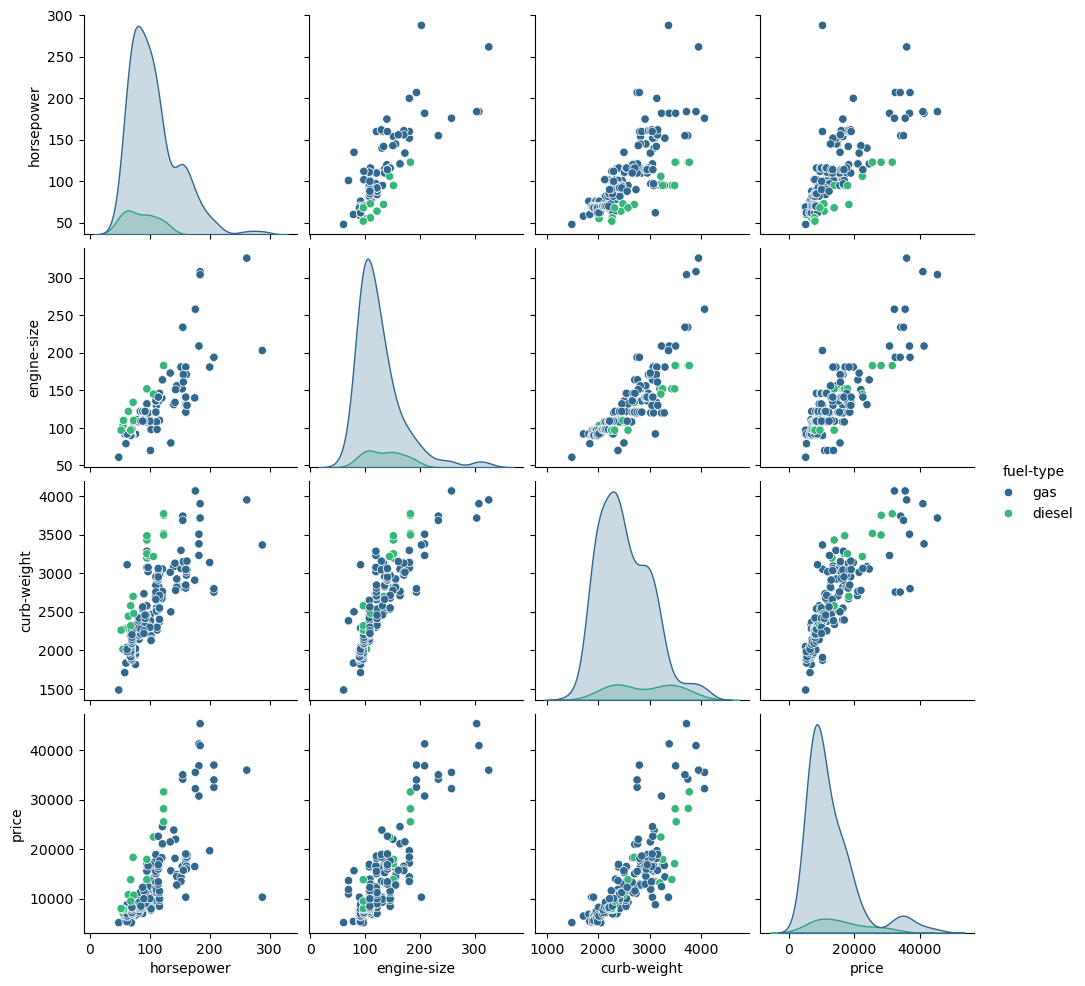

In [4]:
# Багатовимірна візуалізація ключових ознак
sns.pairplot(df[['horsepower', 'engine-size', 'curb-weight', 'price', 'fuel-type']], 
             hue='fuel-type', palette='viridis')
plt.show()

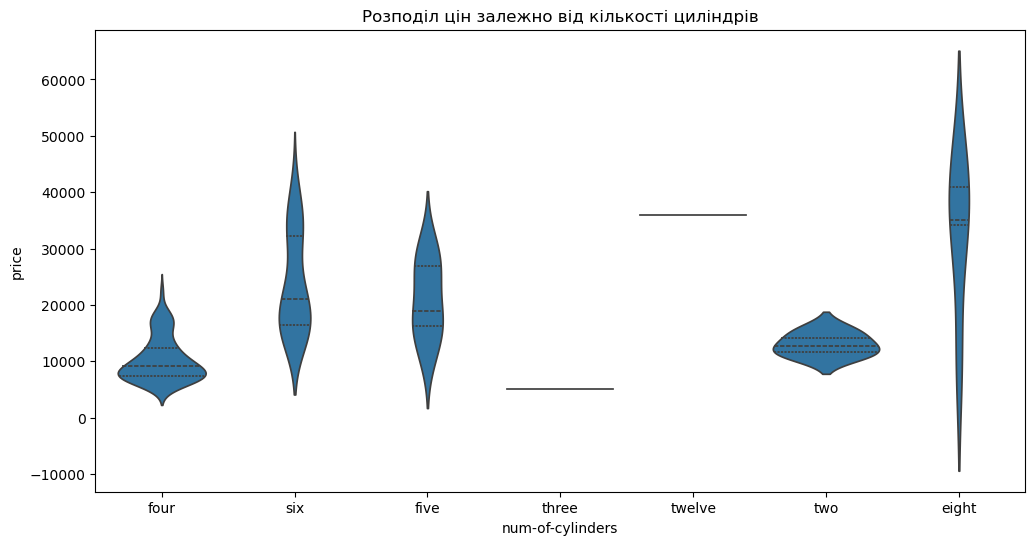

In [5]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='num-of-cylinders', y='price', data=df, inner="quart")
plt.title('Розподіл цін залежно від кількості циліндрів')
plt.show()